In [64]:
# ======================================================================
# CELL-01 : IMPORT LIBRARIES
# ======================================================================

import numpy as np
import pandas as pd

import torch
import torch.nn as nn

from torch.utils.data import (
    TensorDataset,
    DataLoader
)

import joblib

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import matplotlib.pyplot as plt

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [65]:
# ======================================================================
# CELL-02 : LOAD TRAINING DATA
# ======================================================================

X_train = np.load(
    "X_train.npy"
)

Y_train = np.load(
    "Y_train.npy"
)

X_val = np.load(
    "X_val.npy"
)

Y_val = np.load(
    "Y_val.npy"
)

print("Training Data")

print(X_train.shape)

print(Y_train.shape)

print()

print("Validation Data")

print(X_val.shape)

print(Y_val.shape)

Training Data
(42951, 4)
(42951, 4)

Validation Data
(10738, 4)
(10738, 4)


In [66]:
# ======================================================================
# CELL-03 : LOAD OUTPUT SCALER
# ======================================================================

output_scaler = joblib.load(
    "output_scaler.pkl"
)

print("Output Scaler Loaded")


Output Scaler Loaded


In [67]:
# ======================================================================
# CELL-04 : SELECT DEVICE
# ======================================================================

device = torch.device(

    "cuda"

    if torch.cuda.is_available()

    else

    "cpu"

)

print(device)

cuda


In [68]:
# ======================================================================
# CELL-05 : CONVERT TO TENSORS
# ======================================================================

X_train_tensor = torch.tensor(

    X_train,

    dtype=torch.float32

)

Y_train_tensor = torch.tensor(

    Y_train,

    dtype=torch.float32

)

X_val_tensor = torch.tensor(

    X_val,

    dtype=torch.float32

)

Y_val_tensor = torch.tensor(

    Y_val,

    dtype=torch.float32

)

In [69]:
# ======================================================================
# CELL-06 : CREATE DATALOADER
# ======================================================================

train_dataset = TensorDataset(

    X_train_tensor,

    Y_train_tensor

)

train_loader = DataLoader(

    train_dataset,

    batch_size=4096,

    shuffle=True

)

print("Train Loader Ready")

Train Loader Ready


In [70]:
# ======================================================================
# CELL-07 : ANN MODEL
# ======================================================================

class ANN_Model(nn.Module):

    def __init__(self):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(4,256),
            nn.Tanh(),

            nn.Linear(256,256),
            nn.Tanh(),

            nn.Linear(256,256),
            nn.Tanh(),

            nn.Linear(256,128),
            nn.Tanh(),

            nn.Linear(128,64),
            nn.Tanh(),

            nn.Linear(64,4)

        )

    def forward(self,x):

        return self.network(x)

In [71]:
# ======================================================================
# CELL-08 : INITIALIZE MODEL
# ======================================================================

model = ANN_Model().to(device)

print(model)

ANN_Model(
  (network): Sequential(
    (0): Linear(in_features=4, out_features=256, bias=True)
    (1): Tanh()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): Tanh()
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): Tanh()
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): Tanh()
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): Tanh()
    (10): Linear(in_features=64, out_features=4, bias=True)
  )
)


In [72]:
# ======================================================================
# CELL-09 : LOSS FUNCTION
# ======================================================================

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(

    model.parameters(),

    lr=0.001,

)

print("Optimizer Ready")


Optimizer Ready


In [73]:
# ======================================================================
# CELL-10 : TRAINING PARAMETERS
# ======================================================================

epochs = 3000

print(

    "Epochs :",

    epochs

)

Epochs : 3000


In [74]:
# ======================================================================
# CELL-11 : MOVE VALIDATION DATA
# ======================================================================

X_val_gpu = X_val_tensor.to(device)

Y_val_gpu = Y_val_tensor.to(device)

In [75]:
# ======================================================================
# CELL-12 : INITIALIZE TRACKERS
# ======================================================================

train_loss_history = []

validation_loss_history = []

best_validation_loss = np.inf

best_epoch = 0

In [76]:
# ======================================================================
# CELL-13 : TRAIN ANN
# ======================================================================

for epoch in range(epochs):

    model.train()

    epoch_train_loss = 0.0

    for batch_x, batch_y in train_loader:

        batch_x = batch_x.to(device)

        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        predictions = model(
            batch_x
        )

        loss = criterion(

            predictions,

            batch_y

        )

        loss.backward()

        optimizer.step()

        epoch_train_loss += loss.item()

    avg_train_loss = (

        epoch_train_loss

        /

        len(train_loader)

    )

    model.eval()

    with torch.no_grad():

        validation_predictions = model(

            X_val_gpu

        )

        avg_validation_loss = criterion(

            validation_predictions,

            Y_val_gpu

        ).item()

    train_loss_history.append(

        avg_train_loss

    )

    validation_loss_history.append(

        avg_validation_loss

    )

    if avg_validation_loss < best_validation_loss:

        best_validation_loss = avg_validation_loss

        best_epoch = epoch

        torch.save(

            model.state_dict(),

            "ANN_Best_Model.pth"

        )

    if epoch % 100 == 0:

        print(

            f"Epoch {epoch:4d}"

            f" | Train {avg_train_loss:.6f}"

            f" | Val {avg_validation_loss:.6f}"

        )

Epoch    0 | Train 0.009451 | Val 0.004748
Epoch  100 | Train 0.000266 | Val 0.000216
Epoch  200 | Train 0.000163 | Val 0.000136
Epoch  300 | Train 0.000148 | Val 0.000116
Epoch  400 | Train 0.000113 | Val 0.000095
Epoch  500 | Train 0.000079 | Val 0.000069
Epoch  600 | Train 0.000061 | Val 0.000066
Epoch  700 | Train 0.000032 | Val 0.000033
Epoch  800 | Train 0.000029 | Val 0.000033
Epoch  900 | Train 0.000027 | Val 0.000025
Epoch 1000 | Train 0.000022 | Val 0.000025
Epoch 1100 | Train 0.000016 | Val 0.000016
Epoch 1200 | Train 0.000022 | Val 0.000023
Epoch 1300 | Train 0.000017 | Val 0.000020
Epoch 1400 | Train 0.000010 | Val 0.000012
Epoch 1500 | Train 0.000009 | Val 0.000011
Epoch 1600 | Train 0.000009 | Val 0.000011
Epoch 1700 | Train 0.000015 | Val 0.000013
Epoch 1800 | Train 0.000010 | Val 0.000008
Epoch 1900 | Train 0.000010 | Val 0.000008
Epoch 2000 | Train 0.000008 | Val 0.000007
Epoch 2100 | Train 0.000004 | Val 0.000005
Epoch 2200 | Train 0.000004 | Val 0.000007
Epoch 2300 

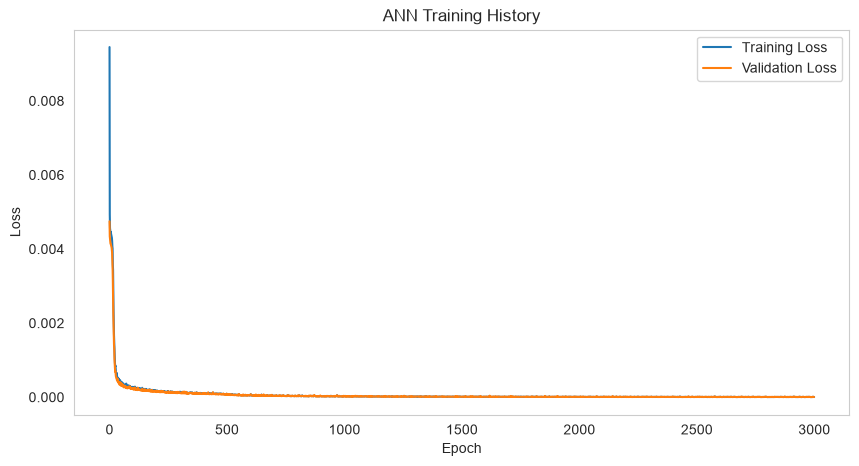

In [77]:
# ======================================================================
# CELL-14 : TRAINING HISTORY
# ======================================================================

plt.figure(

    figsize=(10,5)

)

plt.plot(

    train_loss_history,

    label="Training Loss"

)

plt.plot(

    validation_loss_history,

    label="Validation Loss"

)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("ANN Training History")

plt.legend()

plt.grid()

plt.show()

In [78]:
# ======================================================================
# CELL-15 : BEST MODEL
# ======================================================================

print()

print(

    "Best Epoch :",

    best_epoch

)

print()

print(

    "Best Validation Loss :",

    round(

        best_validation_loss,

        6

    )

)

print()


Best Epoch : 2944

Best Validation Loss : 2e-06



In [79]:
# ======================================================================
# CELL-16 : LOAD BEST MODEL
# ======================================================================

model.load_state_dict(

    torch.load(

        "ANN_Best_Model.pth",

        map_location=device

    )

)

model.eval()

print("Best Model Loaded")

Best Model Loaded


In [80]:
# ======================================================================
# CELL-17 : VALIDATION PREDICTIONS
# ======================================================================

with torch.no_grad():

    predictions_scaled = (

        model(

            X_val_gpu

        )

        .cpu()

        .numpy()

    )

In [81]:
# ======================================================================
# CELL-18 : INVERSE TRANSFORM
# ======================================================================

validation_actual = (

    output_scaler.inverse_transform(

        Y_val

    )

)

validation_predictions = (

    output_scaler.inverse_transform(

        predictions_scaled

    )

)

In [82]:
# ======================================================================
# CELL-19 : METRIC FUNCTION
# ======================================================================

def evaluate_model(

    actual,

    predicted

):

    rmse = np.sqrt(

        mean_squared_error(

            actual,

            predicted

        )

    )

    mae = mean_absolute_error(

        actual,

        predicted

    )

    r2 = r2_score(

        actual,

        predicted

    )

    return rmse, mae, r2

In [83]:
# ======================================================================
# CELL-20 : VALIDATION METRICS
# ======================================================================

outputs = [

    "Displacement",

    "Stress_L1",

    "Stress_L2",

    "Stress_L4"

]

metrics = []

for i, output in enumerate(outputs):

    rmse, mae, r2 = evaluate_model(

        validation_actual[:,i],

        validation_predictions[:,i]

    )

    metrics.append({

        "Output": output,

        "RMSE": rmse,

        "MAE": mae,

        "R2": r2

    })

ann_metrics_df = pd.DataFrame(

    metrics

)

ann_metrics_df.round(4)

,Output,RMSE,MAE,R2
0,Displacement,0.0216,0.0156,0.9999
1,Stress_L1,3.2474,2.1155,0.9987
2,Stress_L2,2.3310,1.4735,0.9993
3,Stress_L4,2.6909,1.5615,0.9992


In [84]:
# ======================================================================
# CELL-21 : SAVE HISTORY
# ======================================================================

history_df = pd.DataFrame({

    "TrainLoss":
    train_loss_history,

    "ValidationLoss":
    validation_loss_history

})

history_df.to_csv(

    "ANN_Training_History.csv",

    index=False

)

print("History Saved")

History Saved


In [85]:
# ======================================================================
# CELL-22 : SAVE SUMMARY
# ======================================================================

summary_df = pd.DataFrame({

    "BestEpoch":[best_epoch],

    "BestValidationLoss":[
        best_validation_loss
    ]

})

summary_df.to_csv(

    "ANN_Training_Summary.csv",

    index=False

)

print("Summary Saved")

Summary Saved


In [86]:
# ======================================================================
# CELL-23 : SAVE VALIDATION METRICS
# ======================================================================

ann_metrics_df.to_csv(

    "ANN_Validation_Metrics.csv",

    index=False

)

print("Metrics Saved")

Metrics Saved


In [87]:
# ======================================================================
# CELL-24 : SAVE VALIDATION PREDICTIONS
# ======================================================================

validation_df = pd.DataFrame({

    "Disp_Actual":
    validation_actual[:,0],

    "Disp_Predicted":
    validation_predictions[:,0],

    "L1_Actual":
    validation_actual[:,1],

    "L1_Predicted":
    validation_predictions[:,1],

    "L2_Actual":
    validation_actual[:,2],

    "L2_Predicted":
    validation_predictions[:,2],

    "L4_Actual":
    validation_actual[:,3],

    "L4_Predicted":
    validation_predictions[:,3]

})

validation_df.to_csv(

    "ANN_Validation_Predictions.csv",

    index=False

)

print("Validation Predictions Saved")

Validation Predictions Saved


In [88]:
# ======================================================================
# CELL-25 : COMPLETION MESSAGE
# ======================================================================

print("="*70)

print("ANN TRAINING COMPLETED SUCCESSFULLY")

print("="*70)

print()

print("="*70)

ANN TRAINING COMPLETED SUCCESSFULLY

Next Notebook : Notebook-04_ML_Benchmarking.ipynb

